# EEC energy-scale comparison
Reads `eec` and `eec_scale_shift` TH1F histograms from ROOT files produced by `eec_pPb_escale_test.py`.
- **Top panel**: distributions overlaid
- **Bottom panel**: ratio `eec / eec_scale_shift` per file

In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import glob, os

# ── file list (edit glob or replace with explicit paths) ─────────────────────
root_files = sorted(glob.glob('eec_pPb_escale_test*.root'))
print('Files found:')
for f in root_files:
    print(' ', f)

Files found:
  eec_pPb_escale_test_scale_shift_-0.6.root
  eec_pPb_escale_test_scale_shift_-1.0.root
  eec_pPb_escale_test_scale_shift_-5.0.root
  eec_pPb_escale_test_scale_shift_0.6.root
  eec_pPb_escale_test_scale_shift_1.0.root
  eec_pPb_escale_test_scale_shift_5.0.root


In [2]:
def get_hist(rf, name):
    """Return (bin_centres, widths, values, errors) for a TH1 in an uproot file."""
    h = rf[name]
    vals, edges = h.to_numpy()
    centres = 0.5 * (edges[:-1] + edges[1:])
    widths  = edges[1:] - edges[:-1]
    errors  = np.sqrt(h.variances()) if h.variances() is not None else np.sqrt(np.abs(vals))
    return centres, widths, vals, errors

def parse_scale_shift(label):
    if 'scale_shift_' in label:
        return float(label.split('scale_shift_')[-1])
    return 0.0

def load_optional(rf, keys, name):
    if name in keys:
        _, _, v, e = get_hist(rf, name)
        return v, e
    return None, None

# ── load all histograms ───────────────────────────────────────────────────────
data = []
for path in root_files:
    label = os.path.basename(path).replace('.root', '')
    ss    = parse_scale_shift(label)
    with uproot.open(path) as rf:
        keys = [k.split(';')[0] for k in rf.keys()]
        centres, widths, eec, eec_err = get_hist(rf, 'eec')
        eec_ss,   eec_ss_err   = load_optional(rf, keys, 'eec_scale_shift')
        eec_wo,   eec_wo_err   = load_optional(rf, keys, 'eec_scale_shift_weight_only')
        if eec_ss is None:
            print(f'  {label}: no eec_scale_shift')
        if eec_wo is None:
            print(f'  {label}: no eec_scale_shift_weight_only')
    data.append(dict(label=label, scale_shift=ss, centres=centres, widths=widths,
                     eec=eec, eec_err=eec_err,
                     eec_ss=eec_ss, eec_ss_err=eec_ss_err,
                     eec_wo=eec_wo, eec_wo_err=eec_wo_err))

abs_vals  = sorted({abs(d['scale_shift']) for d in data if d['scale_shift'] != 0.0})
color_map = {av: plt.cm.tab10.colors[i % 10] for i, av in enumerate(abs_vals)}

print(f'Loaded {len(data)} file(s), {len(data[0]["centres"])} bins each')

Loaded 6 file(s), 15 bins each


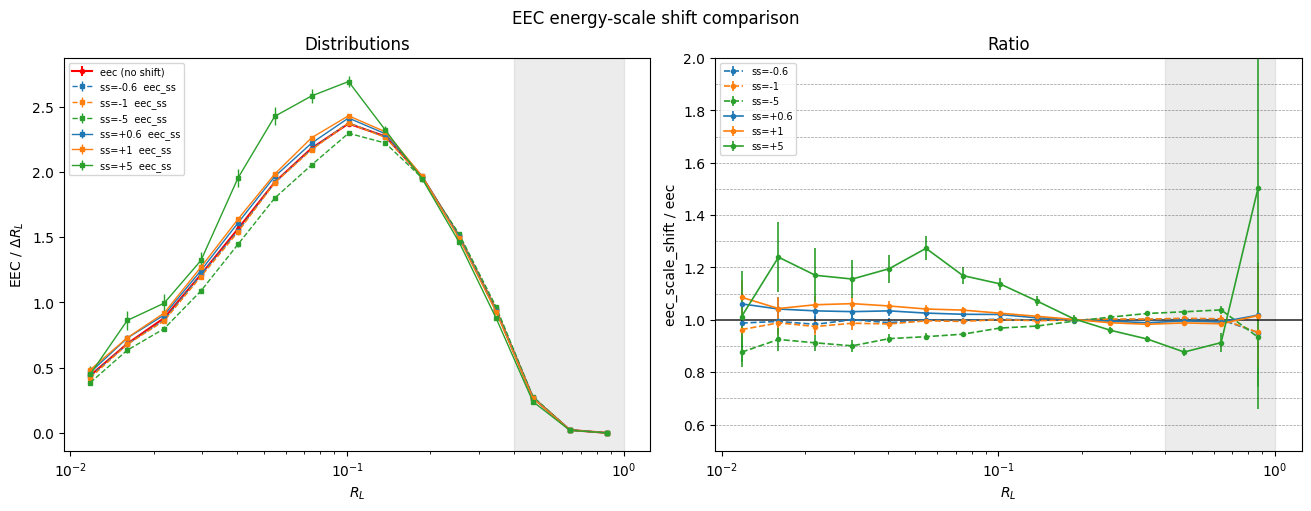

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout='constrained')

def add_rl_band(ax):
    ax.axvspan(0.4, 1.0, color='grey', alpha=0.15, zorder=0)

def style(d):
    ss = d['scale_shift']
    c  = color_map.get(abs(ss), 'black')
    ls = '--' if ss < 0 else '-'
    return c, ls

ref = next((d for d in data if d['scale_shift'] == 0.0), data[0])

# ── left: distributions (divided by bin width) ────────────────────────────────
ax = axes[0]
bw = ref['widths']
ax.errorbar(ref['centres'], ref['eec'] / bw, yerr=ref['eec_err'] / bw,
            fmt='o-', color='red', ms=3, lw=1.5, label='eec (no shift)')
for d in data:
    if d['eec_ss'] is None:
        continue
    c, ls = style(d)
    bw = d['widths']
    ax.errorbar(d['centres'], d['eec_ss'] / bw, yerr=d['eec_ss_err'] / bw,
                fmt='s', color=c, ls=ls, ms=3, lw=1.0,
                label=f"ss={d['scale_shift']:+g}  eec_ss")
add_rl_band(ax)
ax.set_xscale('log')
ax.set_xlabel(r'$R_L$')
ax.set_ylabel(r'EEC / $\Delta R_L$')
ax.set_title('Distributions')
ax.legend(fontsize=7)

# ── right: ratio eec_scale_shift / eec ───────────────────────────────────────
ax = axes[1]
for d in data:
    if d['eec_ss'] is None:
        continue
    c, ls = style(d)
    num = d['eec_ss']
    den = d['eec']
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(den != 0, num / den, np.nan)
        rel_e = np.where((den != 0) & (num != 0),
                         ratio * np.sqrt((d['eec_ss_err'] / np.where(num != 0, num, np.nan))**2 +
                                         (d['eec_err']    / np.where(den != 0, den, np.nan))**2),
                         np.nan)
    ax.errorbar(d['centres'], ratio, yerr=rel_e,
                fmt='o', color=c, ls=ls, ms=3, lw=1.2,
                label=f"ss={d['scale_shift']:+g}")

y_min, y_max = 0.5, 2.0
for y in np.arange(y_min, y_max + 0.05, 0.1):
    lw, ls_g, alpha = (1.2, '-', 0.8) if np.isclose(y, 1.0) else (0.5, '--', 0.4)
    ax.axhline(y, color='k', lw=lw, ls=ls_g, alpha=alpha)
add_rl_band(ax)
ax.set_ylim(y_min, y_max)
ax.set_xscale('log')
ax.set_xlabel(r'$R_L$')
ax.set_ylabel('eec_scale_shift / eec')
ax.set_title('Ratio')
ax.legend(fontsize=7)

plt.suptitle('EEC energy-scale shift comparison')
plt.show()

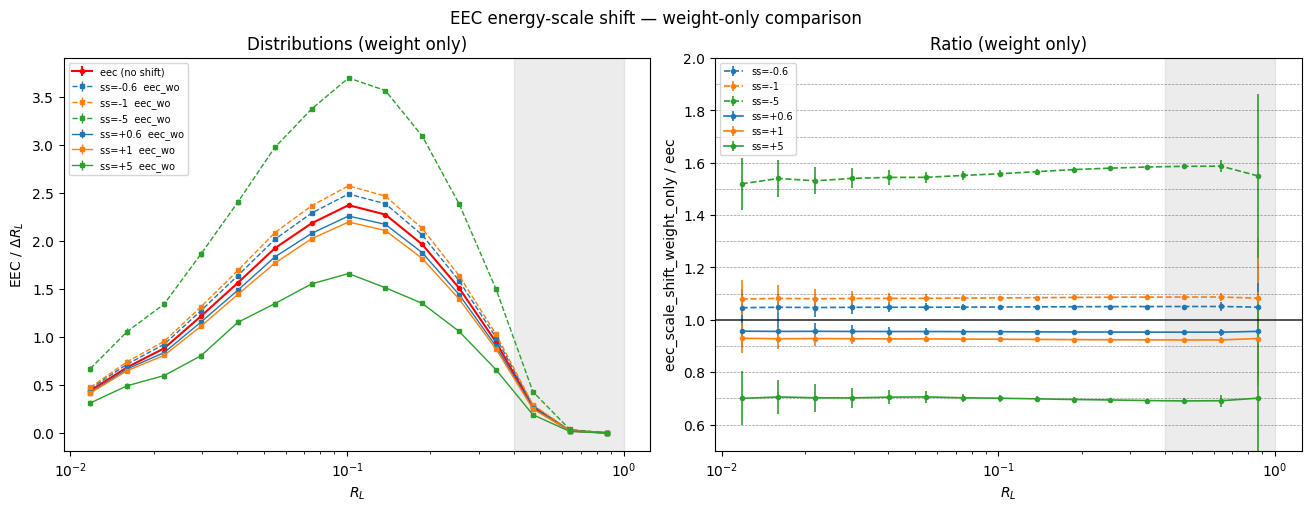

In [4]:
# ── weight-only: distributions + ratio ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout='constrained')

ref = next((d for d in data if d['scale_shift'] == 0.0), data[0])

# left: distributions
ax = axes[0]
bw = ref['widths']
ax.errorbar(ref['centres'], ref['eec'] / bw, yerr=ref['eec_err'] / bw,
            fmt='o-', color='red', ms=3, lw=1.5, label='eec (no shift)')
for d in data:
    if d['eec_wo'] is None:
        continue
    c, ls = style(d)
    bw = d['widths']
    ax.errorbar(d['centres'], d['eec_wo'] / bw, yerr=d['eec_wo_err'] / bw,
                fmt='s', color=c, ls=ls, ms=3, lw=1.0,
                label=f"ss={d['scale_shift']:+g}  eec_wo")
add_rl_band(ax)
ax.set_xscale('log')
ax.set_xlabel(r'$R_L$')
ax.set_ylabel(r'EEC / $\Delta R_L$')
ax.set_title('Distributions (weight only)')
ax.legend(fontsize=7)

# right: ratio eec_scale_shift_weight_only / eec
ax = axes[1]
for d in data:
    if d['eec_wo'] is None:
        continue
    c, ls = style(d)
    num = d['eec_wo']
    den = d['eec']
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(den != 0, num / den, np.nan)
        rel_e = np.where((den != 0) & (num != 0),
                         ratio * np.sqrt((d['eec_wo_err'] / np.where(num != 0, num, np.nan))**2 +
                                         (d['eec_err']    / np.where(den != 0, den, np.nan))**2),
                         np.nan)
    ax.errorbar(d['centres'], ratio, yerr=rel_e,
                fmt='o', color=c, ls=ls, ms=3, lw=1.2,
                label=f"ss={d['scale_shift']:+g}")

y_min, y_max = 0.5, 2.0
for y in np.arange(y_min, y_max + 0.05, 0.1):
    lw, ls_g, alpha = (1.2, '-', 0.8) if np.isclose(y, 1.0) else (0.5, '--', 0.4)
    ax.axhline(y, color='k', lw=lw, ls=ls_g, alpha=alpha)
add_rl_band(ax)
ax.set_ylim(y_min, y_max)
ax.set_xscale('log')
ax.set_xlabel(r'$R_L$')
ax.set_ylabel('eec_scale_shift_weight_only / eec')
ax.set_title('Ratio (weight only)')
ax.legend(fontsize=7)

plt.suptitle('EEC energy-scale shift — weight-only comparison')
plt.show()

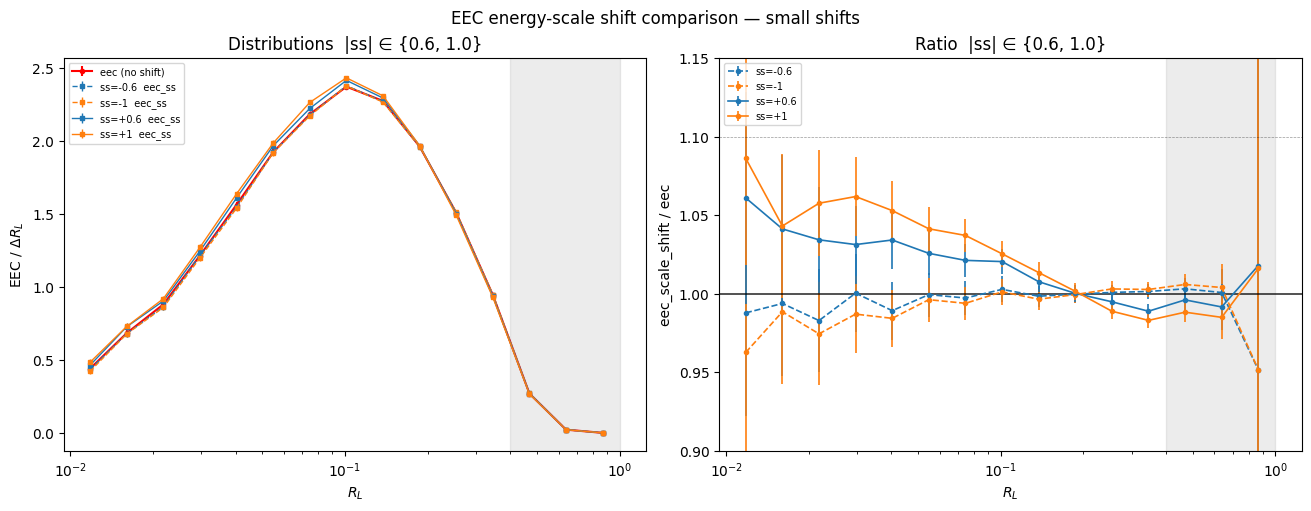

In [5]:
# ── eec_scale_shift: small shifts only (|ss| = 0.6, 1.0) ─────────────────────
focus = [d for d in data if abs(d['scale_shift']) in (0.6, 1.0)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout='constrained')

ax = axes[0]
bw = ref['widths']
ax.errorbar(ref['centres'], ref['eec'] / bw, yerr=ref['eec_err'] / bw,
            fmt='o-', color='red', ms=3, lw=1.5, label='eec (no shift)')
for d in focus:
    if d['eec_ss'] is None:
        continue
    c, ls = style(d)
    bw = d['widths']
    ax.errorbar(d['centres'], d['eec_ss'] / bw, yerr=d['eec_ss_err'] / bw,
                fmt='s', color=c, ls=ls, ms=3, lw=1.0,
                label=f"ss={d['scale_shift']:+g}  eec_ss")
add_rl_band(ax)
ax.set_xscale('log')
ax.set_xlabel(r'$R_L$')
ax.set_ylabel(r'EEC / $\Delta R_L$')
ax.set_title('Distributions  |ss| ∈ {0.6, 1.0}')
ax.legend(fontsize=7)

ax = axes[1]
for d in focus:
    if d['eec_ss'] is None:
        continue
    c, ls = style(d)
    num = d['eec_ss']
    den = d['eec']
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(den != 0, num / den, np.nan)
        rel_e = np.where((den != 0) & (num != 0),
                         ratio * np.sqrt((d['eec_ss_err'] / np.where(num != 0, num, np.nan))**2 +
                                         (d['eec_err']    / np.where(den != 0, den, np.nan))**2),
                         np.nan)
    ax.errorbar(d['centres'], ratio, yerr=rel_e,
                fmt='o', color=c, ls=ls, ms=3, lw=1.2,
                label=f"ss={d['scale_shift']:+g}")

y_min, y_max = 0.9, 1.15
for y in np.arange(y_min, y_max + 0.005, 0.1):
    lw, ls_g, alpha = (1.2, '-', 0.8) if np.isclose(y, 1.0) else (0.5, '--', 0.4)
    ax.axhline(y, color='k', lw=lw, ls=ls_g, alpha=alpha)
add_rl_band(ax)
ax.set_ylim(y_min, y_max)
ax.set_xscale('log')
ax.set_xlabel(r'$R_L$')
ax.set_ylabel('eec_scale_shift / eec')
ax.set_title('Ratio  |ss| ∈ {0.6, 1.0}')
ax.legend(fontsize=7)

plt.suptitle('EEC energy-scale shift comparison — small shifts')
plt.show()

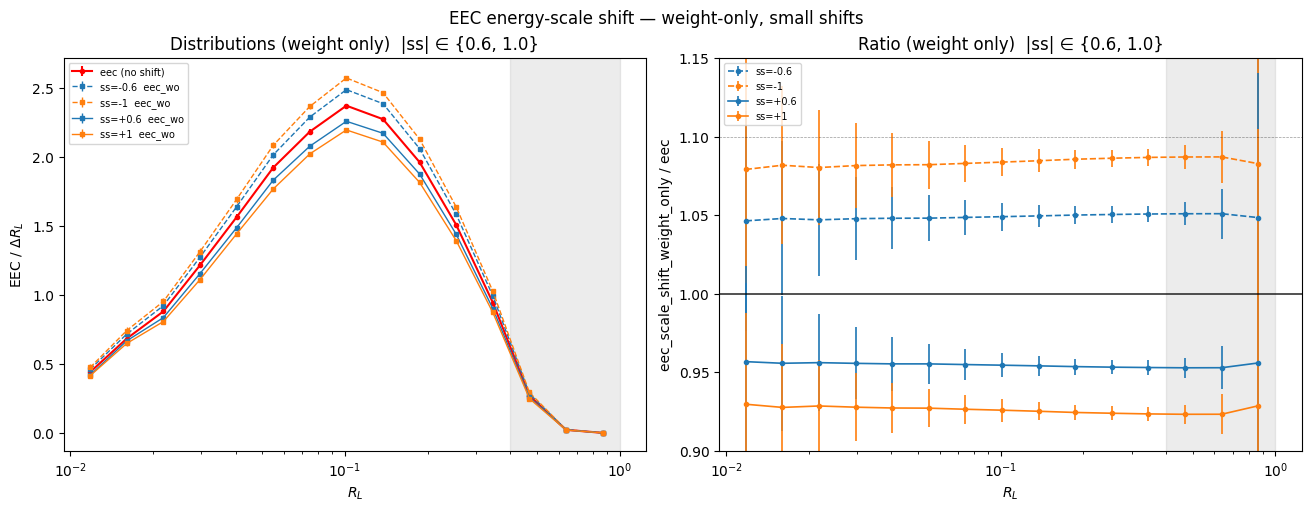

In [6]:
# ── eec_scale_shift_weight_only: small shifts only (|ss| = 0.6, 1.0) ──────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout='constrained')

ax = axes[0]
bw = ref['widths']
ax.errorbar(ref['centres'], ref['eec'] / bw, yerr=ref['eec_err'] / bw,
            fmt='o-', color='red', ms=3, lw=1.5, label='eec (no shift)')
for d in focus:
    if d['eec_wo'] is None:
        continue
    c, ls = style(d)
    bw = d['widths']
    ax.errorbar(d['centres'], d['eec_wo'] / bw, yerr=d['eec_wo_err'] / bw,
                fmt='s', color=c, ls=ls, ms=3, lw=1.0,
                label=f"ss={d['scale_shift']:+g}  eec_wo")
add_rl_band(ax)
ax.set_xscale('log')
ax.set_xlabel(r'$R_L$')
ax.set_ylabel(r'EEC / $\Delta R_L$')
ax.set_title('Distributions (weight only)  |ss| ∈ {0.6, 1.0}')
ax.legend(fontsize=7)

ax = axes[1]
for d in focus:
    if d['eec_wo'] is None:
        continue
    c, ls = style(d)
    num = d['eec_wo']
    den = d['eec']
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(den != 0, num / den, np.nan)
        rel_e = np.where((den != 0) & (num != 0),
                         ratio * np.sqrt((d['eec_wo_err'] / np.where(num != 0, num, np.nan))**2 +
                                         (d['eec_err']    / np.where(den != 0, den, np.nan))**2),
                         np.nan)
    ax.errorbar(d['centres'], ratio, yerr=rel_e,
                fmt='o', color=c, ls=ls, ms=3, lw=1.2,
                label=f"ss={d['scale_shift']:+g}")

y_min, y_max = 0.9, 1.15
for y in np.arange(y_min, y_max + 0.005, 0.1):
    lw, ls_g, alpha = (1.2, '-', 0.8) if np.isclose(y, 1.0) else (0.5, '--', 0.4)
    ax.axhline(y, color='k', lw=lw, ls=ls_g, alpha=alpha)
add_rl_band(ax)
ax.set_ylim(y_min, y_max)
ax.set_xscale('log')
ax.set_xlabel(r'$R_L$')
ax.set_ylabel('eec_scale_shift_weight_only / eec')
ax.set_title('Ratio (weight only)  |ss| ∈ {0.6, 1.0}')
ax.legend(fontsize=7)

plt.suptitle('EEC energy-scale shift — weight-only, small shifts')
plt.show()